# EDA - Harga Pasar (SISKAPERBAPO)

**Catatan penting:** missing value di data ini tersamar sebagai `harga = 0` (scraper mengubah `-` menjadi 0), BUKAN NaN. Jadi semua pengecekan missing harus pakai `harga == 0`.

## 1. Import Library

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import glob, os

plt.rcParams['figure.figsize'] = (14, 5)

## 2. Load Data Pasar

In [2]:
data_pasar = []
for path in sorted(glob.glob('../data/raw/pasar/data_*_kalender.csv')):
    nama = os.path.basename(path).replace('data_', '').replace('_kalender.csv', '').replace('_', ' ').title()
    tmp = pd.read_csv(path)
    tmp['pasar'] = nama
    data_pasar.append(tmp)

data_pasar = pd.concat(data_pasar, ignore_index=True)
data_pasar['tanggal'] = pd.to_datetime(data_pasar['tanggal'])

print(f"{len(data_pasar):,} baris | {data_pasar['pasar'].nunique()} pasar | {data_pasar['komoditas'].nunique()} komoditas")
data_pasar.head()

613,620 baris | 6 pasar | 42 komoditas


,tanggal,komoditas_id,komoditas,grup,satuan,harga_kemarin,harga,hari_nama,is_weekend,is_libur_nasional,nama_libur,is_ramadan,is_pra_ramadan,pasar
0,2020-01-05,2,Beras Premium,BERAS,kg,0,0,Minggu,1,0,NaN,0,0,Soponyono
1,2020-01-05,4,Beras Medium,BERAS,kg,0,0,Minggu,1,0,NaN,0,0,Soponyono
2,2020-01-05,7,Gula Kristal Putih,GULA,kg,0,0,Minggu,1,0,NaN,0,0,Soponyono
3,2020-01-05,10,Minyak Goreng Curah,MINYAK GORENG,kg,0,0,Minggu,1,0,NaN,0,0,Soponyono
4,2020-01-05,92,Minyak Goreng Kemasan Premium,MINYAK GORENG,1 liter,0,0,Minggu,1,0,NaN,0,0,Soponyono


In [3]:
data_pasar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613620 entries, 0 to 613619
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   tanggal            613620 non-null  datetime64[ns]
 1   komoditas_id       613620 non-null  int64         
 2   komoditas          613620 non-null  object        
 3   grup               613620 non-null  object        
 4   satuan             613620 non-null  object        
 5   harga_kemarin      613620 non-null  int64         
 6   harga              613620 non-null  int64         
 7   hari_nama          613620 non-null  object        
 8   is_weekend         613620 non-null  int64         
 9   is_libur_nasional  613620 non-null  int64         
 10  nama_libur         41580 non-null   object        
 11  is_ramadan         613620 non-null  int64         
 12  is_pra_ramadan     613620 non-null  int64         
 13  pasar              613620 non-null  object  

In [4]:
print(data_pasar['pasar'].value_counts())
print()
print(data_pasar['grup'].value_counts())

pasar
Soponyono      102270
Genteng        102270
Keputran       102270
Pucang Anom    102270
Tambahrejo     102270
Wonokromo      102270
Name: count, dtype: int64

grup
IKAN SEGAR               73050
SAYUR MAYUR              73050
MINYAK GORENG            58440
SUSU                     58440
DAGING                   43830
CABE                     43830
BERAS                    29220
BAWANG                   29220
KACANG KEDELAI           29220
TELUR AYAM               29220
GARAM BERYODIUM          29220
GULA                     14610
MIE INSTANT              14610
Jagung Pipilan Kering    14610
TEPUNG TERIGU            14610
KACANG HIJAU             14610
Ikan Asin Teri           14610
KETELA POHON             14610
KACANG TANAH             14610
Name: count, dtype: int64


## 3. Missing Value (harga = 0)

In [5]:
data_pasar['missing'] = data_pasar['harga'] == 0

print(f"Total baris harga=0 : {data_pasar['missing'].sum():,} ({data_pasar['missing'].mean()*100:.1f}%)")
print(f"Total NaN sesungguhnya: {data_pasar['harga'].isna().sum()}")

Total baris harga=0 : 132,772 (21.6%)
Total NaN sesungguhnya: 0


In [6]:
missing_tahun = (data_pasar.groupby(['pasar', data_pasar['tanggal'].dt.year])['missing']
                 .mean().mul(100).round(1).unstack())
missing_tahun

tanggal,2020,2021,2022,2023,2024,2025,2026
pasar,,,,,,,
Genteng,11.9,14.0,16.9,14.4,16.6,16.7,16.7
Keputran,20.5,17.6,22.4,19.5,26.6,25.4,19.7
Pucang Anom,7.1,7.1,11.5,7.9,8.0,7.1,7.1
Soponyono,100.0,100.0,77.9,7.6,10.7,12.4,12.8
Tambahrejo,9.5,13.8,13.6,19.8,22.9,21.2,16.7
Wonokromo,21.4,20.0,21.6,18.9,21.1,19.7,20.0


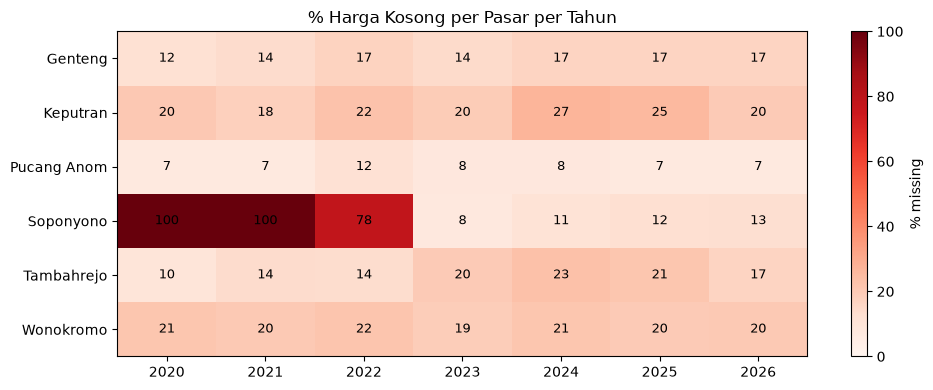

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(missing_tahun.values, cmap='Reds', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(missing_tahun.columns)), missing_tahun.columns)
ax.set_yticks(range(len(missing_tahun.index)), missing_tahun.index)
for i in range(missing_tahun.shape[0]):
    for j in range(missing_tahun.shape[1]):
        ax.text(j, i, f"{missing_tahun.values[i, j]:.0f}", ha='center', va='center', fontsize=9)
fig.colorbar(im, label='% missing')
ax.set_title('% Harga Kosong per Pasar per Tahun')
plt.tight_layout()
plt.show()

**Ekspektasi:** Soponyono 2020-2021 = 100% kosong (pasar baru masuk titik pantau ~2023), Keputran & Tambahrejo naik sejak 2023, Pucang Anom terbaik stabil ~7%.

## 4. Cek Tanggal Bolong & Duplikat

In [8]:
for pasar, g in data_pasar.groupby('pasar'):
    full = pd.date_range(g['tanggal'].min(), g['tanggal'].max(), freq='D')
    bolong = sorted(set(full) - set(g['tanggal'].unique()))
    print(f"{pasar:12s} {g['tanggal'].min().date()} -> {g['tanggal'].max().date()} | hari bolong: {len(bolong)}")
    if bolong:
        print('    contoh:', [d.date().isoformat() for d in bolong[:5]])

dup = data_pasar.duplicated(subset=['pasar', 'tanggal', 'komoditas_id']).sum()
print(f"\nDuplikat pasar x tanggal x komoditas_id: {dup}")

Genteng      2020-01-01 -> 2026-08-31 | hari bolong: 0
Keputran     2020-01-01 -> 2026-08-31 | hari bolong: 0
Pucang Anom  2020-01-01 -> 2026-08-31 | hari bolong: 0
Soponyono    2020-01-01 -> 2026-08-31 | hari bolong: 0
Tambahrejo   2020-01-01 -> 2026-08-31 | hari bolong: 0
Wonokromo    2020-01-01 -> 2026-08-31 | hari bolong: 0

Duplikat pasar x tanggal x komoditas_id: 0


## 5. Konsistensi harga_kemarin vs Harga Hari Sebelumnya

In [9]:
data_pasar = data_pasar.sort_values(['pasar', 'komoditas_id', 'tanggal']).reset_index(drop=True)
data_pasar['harga_prev'] = data_pasar.groupby(['pasar', 'komoditas_id'])['harga'].shift(1)

mismatch = (data_pasar['harga_prev'].notna()
            & (data_pasar['harga_prev'] > 0)
            & (data_pasar['harga_kemarin'] > 0)
            & (data_pasar['harga_prev'] != data_pasar['harga_kemarin']))

print(f"Mismatch: {mismatch.sum():,} baris ({mismatch.mean()*100:.2f}%)")
print('\nKomoditas paling sering mismatch:')
print(data_pasar.loc[mismatch, 'komoditas'].value_counts().head(10))

Mismatch: 0 baris (0.00%)

Komoditas paling sering mismatch:
Series([], Name: count, dtype: int64)


## 6. Seri Paling Rusak (2023+) - Kandidat Dibuang

Aturan: total missing > 30% per seri komoditas x pasar -> tidak layak untuk training.

In [10]:
data23 = data_pasar[data_pasar['tanggal'] >= '2023-01-01'].copy()

kosong = (data23.groupby(['pasar', 'komoditas'])['missing'].mean()
          .mul(100).round(1))
rusak = kosong[kosong > 30].sort_values(ascending=False)
print(f"Seri dengan missing >30% (2023+): {len(rusak)} dari {data23.groupby(['pasar','komoditas']).ngroups}")
rusak.head(20)

Seri dengan missing >30% (2023+): 47 dari 252


pasar        komoditas                         
Genteng      Ikan Cakalang                         100.0
             Ikan Kembung                          100.0
             Ikan Tuna                             100.0
             Kedelai Lokal                         100.0
             Minyak Goreng Kemasan Sederhana       100.0
             Susu Bubuk Merk Indomilk (Instant)    100.0
Keputran     Ikan Cakalang                         100.0
             Ikan Tuna                             100.0
Soponyono    Susu Bubuk Merk Bendera (Instant)     100.0
Pucang Anom  Susu Bubuk Merk Indomilk (Instant)    100.0
             Susu Bubuk Merk Bendera (Instant)     100.0
Keputran     Susu Bubuk Merk Indomilk (Instant)    100.0
Pucang Anom  Minyak Goreng Kemasan Sederhana       100.0
Keputran     Susu Bubuk Merk Bendera (Instant)     100.0
             Minyak Goreng Kemasan Sederhana       100.0
Wonokromo    Ikan Tuna                             100.0
             Ikan Cakalang              

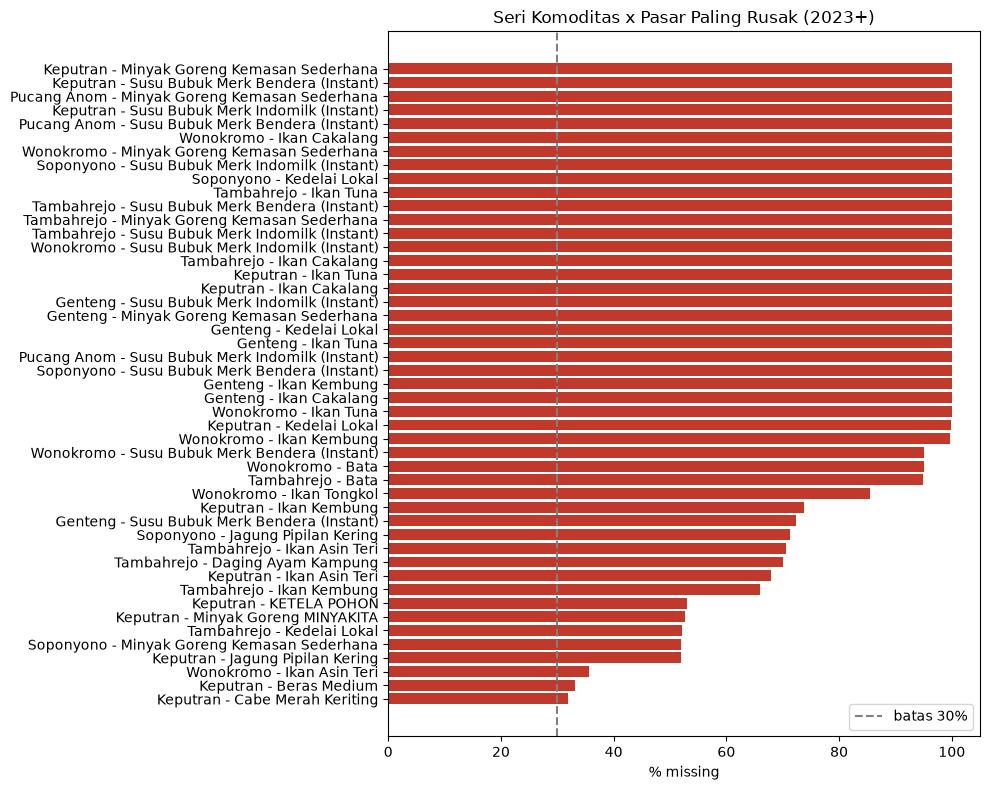

In [11]:
top_rusak = rusak.sort_values()
labels = [f'{p} - {k}' for p, k in top_rusak.index]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(labels, top_rusak.values, color='#c0392b')
ax.axvline(30, color='gray', linestyle='--', label='batas 30%')
ax.set_xlabel('% missing')
ax.set_title('Seri Komoditas x Pasar Paling Rusak (2023+)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Distribusi & Outlier Harga (2023+)

In [12]:
stat = (data23[data23['harga'] > 0]
        .groupby('komoditas')['harga']
        .agg(median='median', mean='mean', std='std', min='min', max='max')
        .round(0)
        .sort_values('median'))
stat

,median,mean,std,min,max
komoditas,,,,,
Bata,1500.0,1427.0,711.0,250,2000
Indomie Rasa Kari Ayam,3200.0,3166.0,166.0,3000,3500
KETELA POHON,6000.0,6018.0,958.0,5000,8000
Halus,8000.0,8579.0,1214.0,6000,12000
KOL/KUBIS,9000.0,9011.0,1903.0,5000,20000
Jagung Pipilan Kering,11000.0,10767.0,1348.0,7000,15000
Beras Medium,12000.0,12036.0,1279.0,8800,15000
Terigu Protein Sedang (Kemasan),12000.0,12368.0,620.0,10000,15000
Tomat Merah,12000.0,13579.0,5352.0,4000,35000


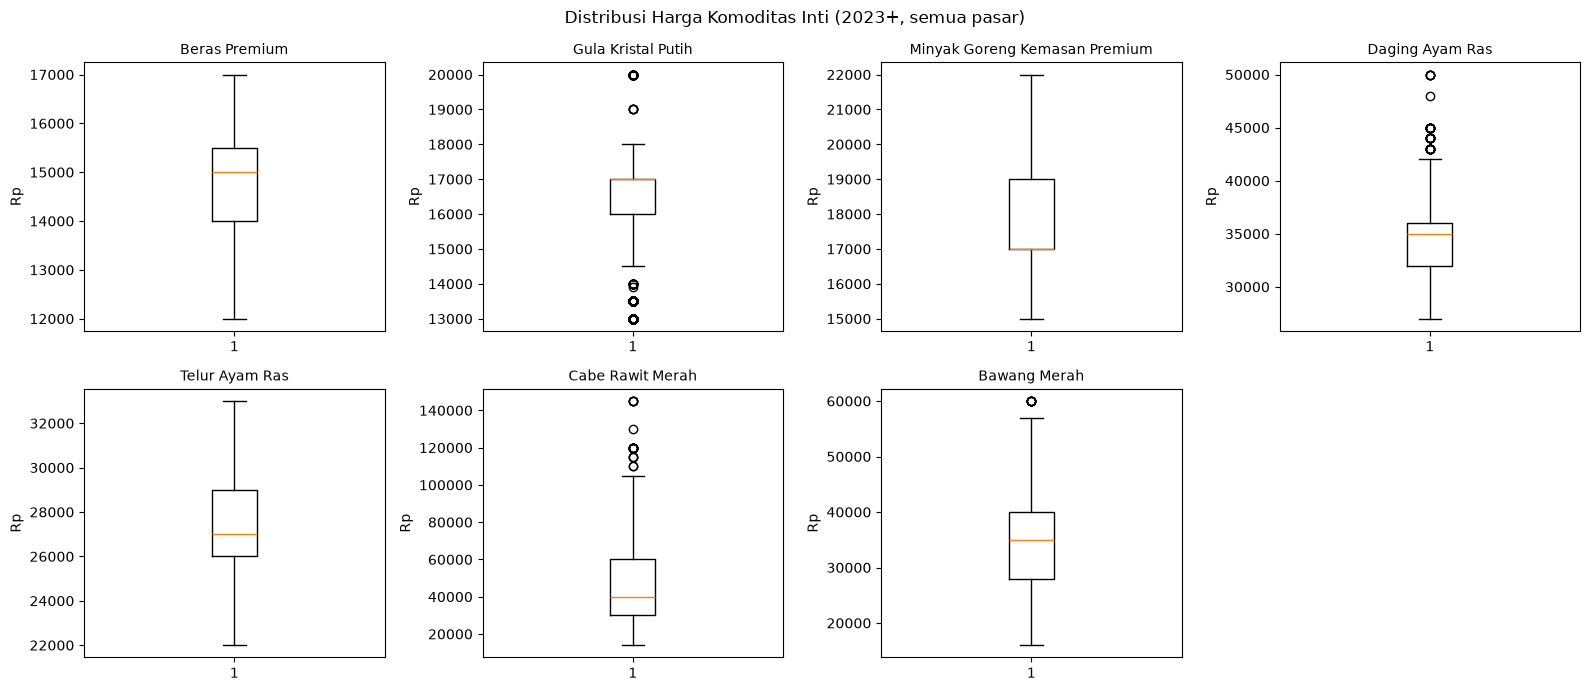

In [13]:
kom_plot = ['Beras Premium', 'Gula Kristal Putih', 'Minyak Goreng Kemasan Premium',
            'Daging Ayam Ras', 'Telur Ayam Ras', 'Cabe Rawit Merah', 'Bawang Merah']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, k in zip(axes.flat, kom_plot):
    nilai = data23[(data23['komoditas'] == k) & (data23['harga'] > 0)]['harga']
    ax.boxplot(nilai)
    ax.set_title(k, fontsize=10)
    ax.set_ylabel('Rp')
axes.flat[-1].axis('off')
fig.suptitle('Distribusi Harga Komoditas Inti (2023+, semua pasar)')
plt.tight_layout()
plt.show()

In [14]:
data23 = data23.sort_values(['pasar', 'komoditas_id', 'tanggal']).copy()
data23['pct'] = data23.groupby(['pasar', 'komoditas_id'])['harga'].pct_change()

ekstrem = data23[(data23['pct'].abs() > 0.5) & (data23['harga'] > 0)]
print(f"Lonjakan > +/-50% dalam 1 hari: {len(ekstrem)} baris")
print(ekstrem['komoditas'].value_counts().head(10))
ekstrem[['tanggal', 'pasar', 'komoditas', 'harga_prev', 'harga', 'pct']].head(15)

Lonjakan > +/-50% dalam 1 hari: 276 baris
komoditas
Cabe Rawit Merah           42
BUNCIS                     33
Cabe Merah Keriting        26
Cabe Merah Besar           25
Tomat Merah                22
Minyak Goreng MINYAKITA    14
Ikan Tongkol               13
Ikan Asin Teri             12
KOL/KUBIS                  11
Beras Medium               11
Name: count, dtype: int64


,tanggal,pasar,komoditas,harga_prev,harga,pct
42683,2023-07-12,Genteng,Kedelai Impor,0.0,12000,inf
50099,2023-10-31,Genteng,Cabe Merah Keriting,28000.0,50000,0.785714
50242,2024-03-22,Genteng,Cabe Merah Keriting,0.0,30000,inf
50525,2024-12-30,Genteng,Cabe Merah Keriting,30000.0,50000,0.666667
53114,2025-06-02,Genteng,Cabe Merah Besar,25000.0,40000,0.600000
69789,2024-05-28,Genteng,KENTANG,12000.0,20000,0.666667
74919,2025-02-12,Genteng,WORTEL,15000.0,25000,0.666667
77010,2024-03-05,Genteng,BUNCIS,10000.0,17000,0.700000
77019,2024-03-14,Genteng,BUNCIS,18000.0,29000,0.611111
77107,2024-06-10,Genteng,BUNCIS,7000.0,12000,0.714286


## 8. Tren Harga Komoditas Inti (median 6 pasar, bulanan)

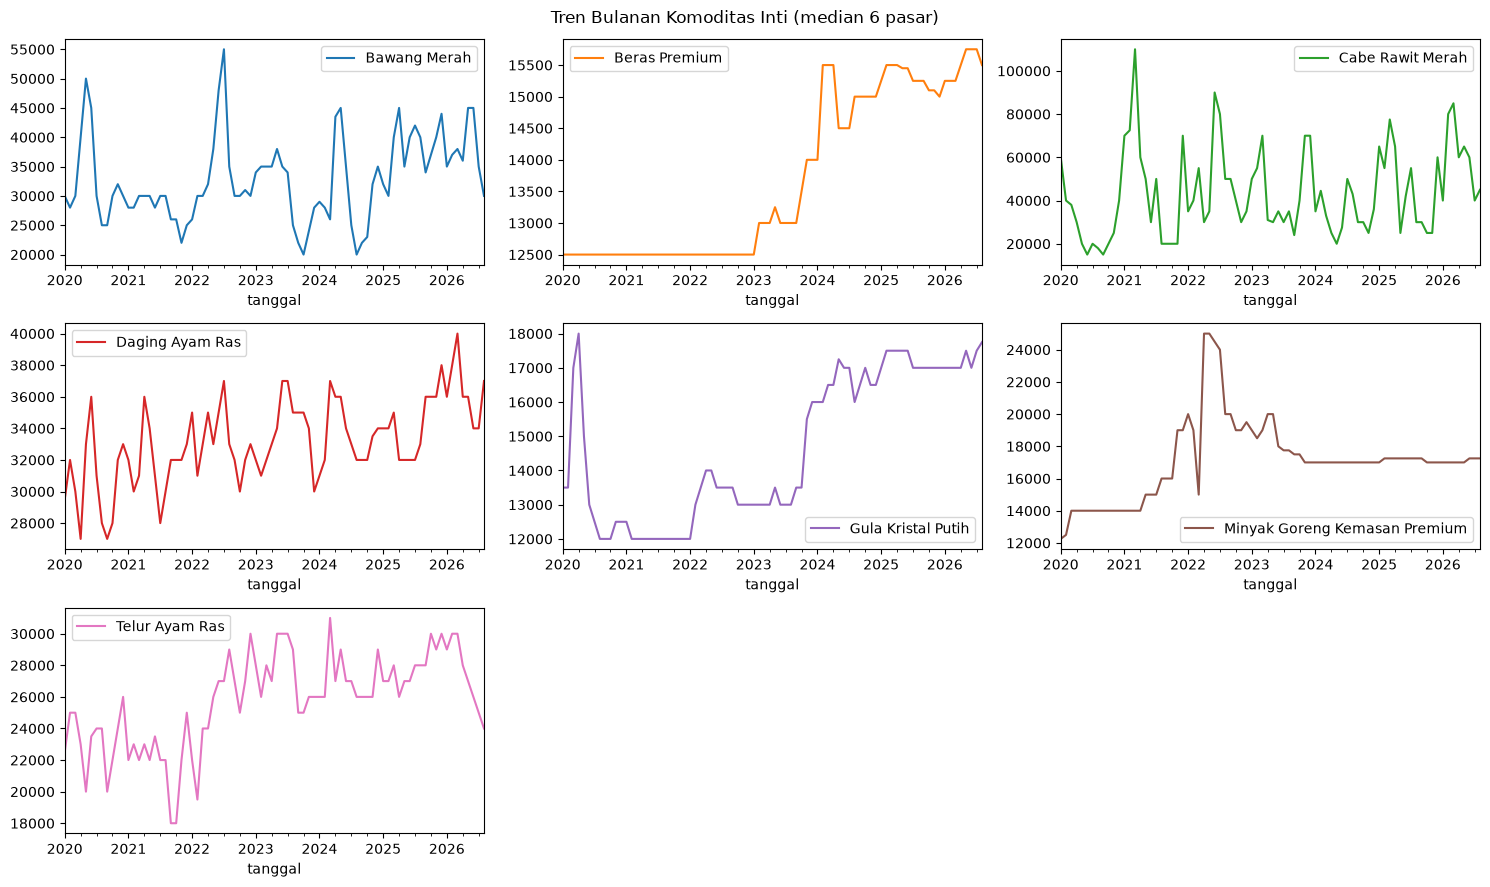

In [15]:
bulan = (data_pasar[data_pasar['komoditas'].isin(kom_plot) & (data_pasar['harga'] > 0)]
         .groupby([pd.Grouper(key='tanggal', freq='MS'), 'komoditas'])['harga']
         .median().unstack())

bulan.plot(subplots=True, layout=(3, 3), figsize=(15, 9),
           title='Tren Bulanan Komoditas Inti (median 6 pasar)', sharex=False)
plt.tight_layout()
plt.show()

## 9. Pola Musiman & Efek Ramadan

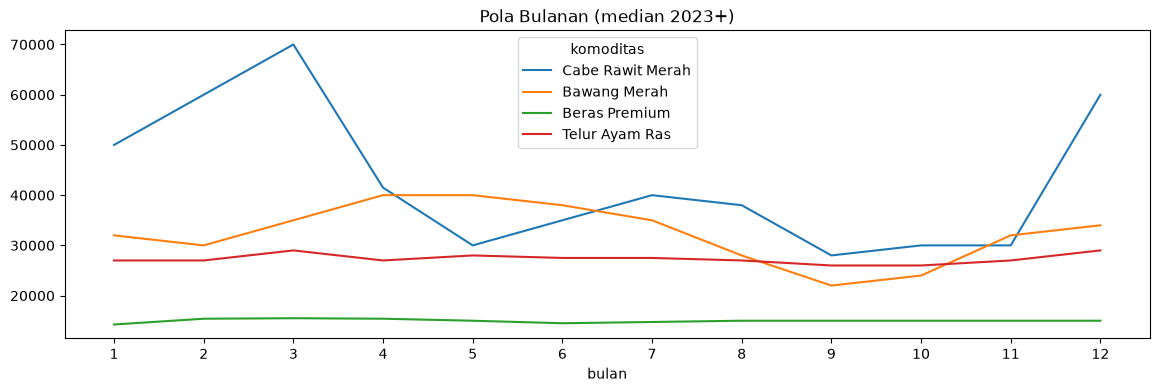

In [16]:
data23['bulan'] = data23['tanggal'].dt.month
musim = (data23[data23['harga'] > 0]
         .pivot_table(index='bulan', columns='komoditas', values='harga', aggfunc='median'))

musim[['Cabe Rawit Merah', 'Bawang Merah', 'Beras Premium', 'Telur Ayam Ras']] \
    .plot(figsize=(14, 4), title='Pola Bulanan (median 2023+)')
plt.xticks(range(1, 13))
plt.show()

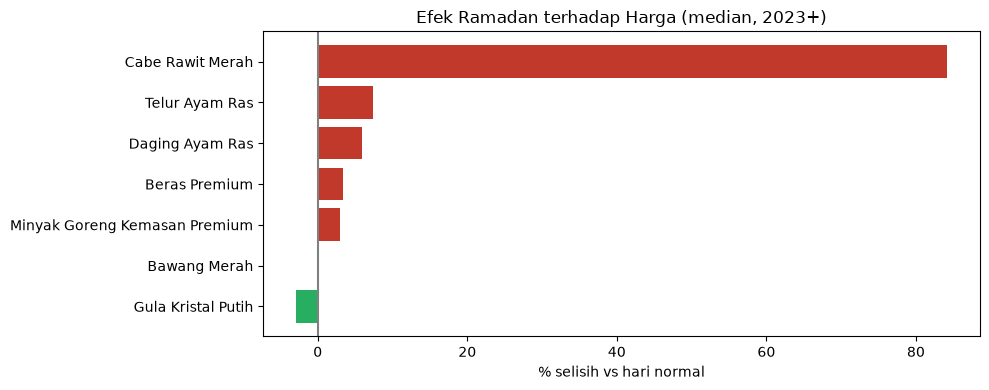

fase,normal,pra_ramadan,ramadan
komoditas,,,
Bawang Merah,35000.0,32000.0,35000.0
Beras Premium,15000.0,15500.0,15500.0
Cabe Rawit Merah,38000.0,70000.0,70000.0
Daging Ayam Ras,34000.0,35000.0,36000.0
Gula Kristal Putih,17000.0,16500.0,16500.0
Minyak Goreng Kemasan Premium,17000.0,17500.0,17500.0
Telur Ayam Ras,27000.0,29250.0,29000.0


In [17]:
data23['fase'] = np.select(
    [data23['is_pra_ramadan'] == 1, data23['is_ramadan'] == 1],
    ['pra_ramadan', 'ramadan'],
    default='normal')

fase = (data23[data23['komoditas'].isin(kom_plot) & (data23['harga'] > 0)]
        .groupby(['komoditas', 'fase'])['harga'].median().unstack().round(0))

selisih = ((fase['ramadan'] - fase['normal']) / fase['normal'] * 100).sort_values()
fig, ax = plt.subplots(figsize=(10, 4))
warna = ['#27ae60' if x < 0 else '#c0392b' for x in selisih]
ax.barh(selisih.index, selisih.values, color=warna)
ax.axvline(0, color='gray')
ax.set_xlabel('% selisih vs hari normal')
ax.set_title('Efek Ramadan terhadap Harga (median, 2023+)')
plt.tight_layout()
plt.show()
fase

## 10. Perbandingan Antar Pasar

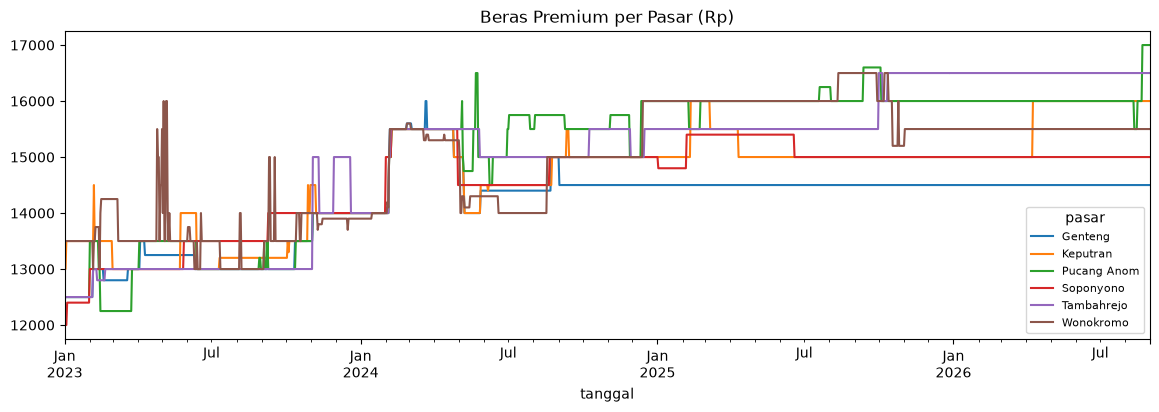

In [18]:
p_beras = (data23[(data23['komoditas'] == 'Beras Premium') & (data23['harga'] > 0)]
           .pivot_table(index='tanggal', columns='pasar', values='harga'))
p_beras.plot(figsize=(14, 4), title='Beras Premium per Pasar (Rp)')
plt.legend(title='pasar', fontsize=8)
plt.show()

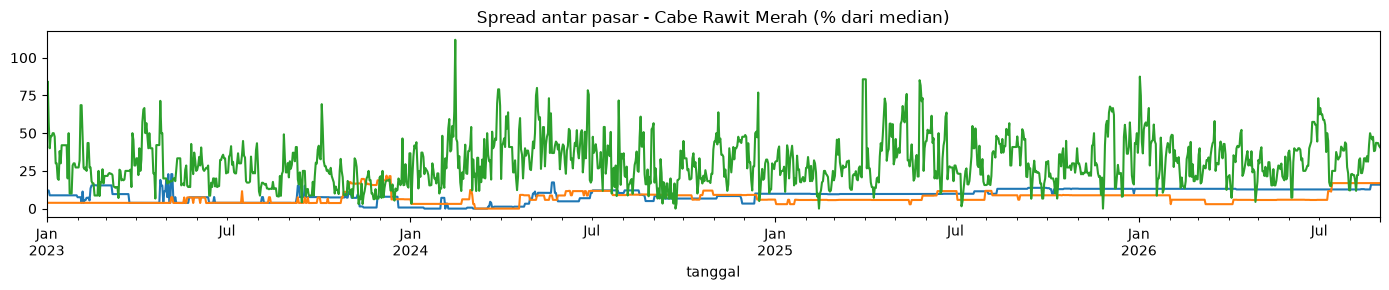

In [19]:
for k in ['Beras Premium', 'Gula Kristal Putih', 'Cabe Rawit Merah']:
    p = (data23[(data23['komoditas'] == k) & (data23['harga'] > 0)]
         .pivot_table(index='tanggal', columns='pasar', values='harga'))
    spread_pct = ((p.max(axis=1) - p.min(axis=1)) / p.median(axis=1) * 100)
    spread_pct.plot(figsize=(14, 3), title=f'Spread antar pasar - {k} (% dari median)')
plt.tight_layout()
plt.show()

## 11. Korelasi Cuaca vs Harga (contoh: Cabe Rawit Merah)

In [20]:
cuaca = pd.read_csv('../data/external/cuaca/cuaca_surabaya.csv', parse_dates=['tanggal'])

cabe = (data23[(data23['komoditas'] == 'Cabe Rawit Merah') & (data23['harga'] > 0)]
        .groupby('tanggal')['harga'].median().rename('harga_cabe').reset_index())
cabe = cabe.merge(cuaca[['tanggal', 'curah_hujan_mm']], on='tanggal')
minggu = (cabe.set_index('tanggal').resample('W').mean())

for lag in [0, 2, 4, 8]:
    korr = minggu['harga_cabe'].corr(minggu['curah_hujan_mm'].shift(lag))
    print(f"lag {lag} minggu: korelasi harga cabe vs curah hujan = {korr:.3f}")

lag 0 minggu: korelasi harga cabe vs curah hujan = 0.259
lag 2 minggu: korelasi harga cabe vs curah hujan = 0.322
lag 4 minggu: korelasi harga cabe vs curah hujan = 0.375
lag 8 minggu: korelasi harga cabe vs curah hujan = 0.224


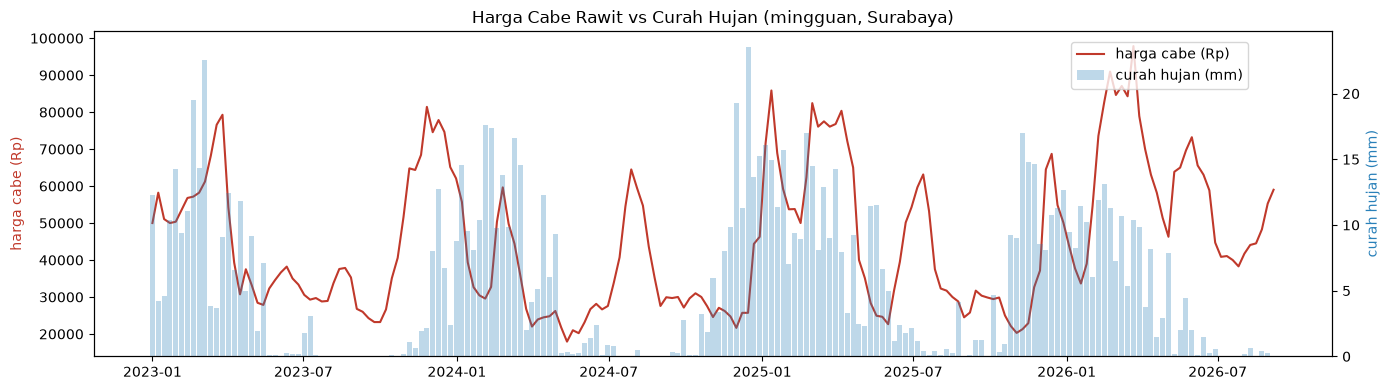

In [21]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(minggu.index, minggu['harga_cabe'], color='#c0392b', label='harga cabe (Rp)')
ax1.set_ylabel('harga cabe (Rp)', color='#c0392b')
ax2 = ax1.twinx()
ax2.bar(minggu.index, minggu['curah_hujan_mm'], width=6, alpha=0.3, color='#2980b9', label='curah hujan (mm)')
ax2.set_ylabel('curah hujan (mm)', color='#2980b9')
ax1.set_title('Harga Cabe Rawit vs Curah Hujan (mingguan, Surabaya)')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

## 12. Ringkasan Temuan

1. Missing tersamar sebagai 0 - total ~22% baris; wajib konversi ke NaN di preprocessing.
2. Soponyono efektif baru mulai 2023 (2020-22 kosong 78-100%) -> trim periode.
3. Keputran & Tambahrejo degradasi - missing naik sejak 2023.
4. Komoditas mati sejak 2023 di semua pasar: Minyak Goreng Kemasan Sederhana, Susu Bubuk Bendera/Indomilk, Kedelai Lokal.
5. Bocoran non-pangan: Bata (garam bata ternak) -> buang; Halus (Garam Beryodium Halus) -> rename.
6. Komoditas inti (beras, gula, minyak, daging, telur) 100% terisi -> tulang punggung model.
7. Seri ikan paling rapuh di Keputran & Wonokromo -> model ikan pakai Pucang Anom/Genteng.
8. Outlier: lonjakan > +/-50% mayoritas di komoditas volatil (cabe/bawang/sayur) - lonjakan riil, bukan error input.
9. Cabe naik tajam menjelang & selama Ramadan (~84% di atas normal) - fitur kalender penting untuk model.
10. Korelasi hujan -> harga cabe paling kuat di lag 4 minggu (~0.38) - hujan bisa jadi fitur prediktif.

Rekomendasi preprocessing (notebook/preprocessing.ipynb):
```
0 -> NaN  ->  drop komoditas mati/non-pangan  ->  rename Halus
->  reindex kalender per komoditas  ->  ffill limit 3
->  interpolasi gap 4-14 hari + flag imputed
->  seri gap >14 hari (volatil: >7) -> potong/buang
->  Soponyono: hanya 2023+
```